# Linear Regression
**INDE 577 / CMOR 438 — Jingru Wu, Rice University**

---

## 1. Mathematical Background

Given a dataset $\{(\mathbf{x}_i, y_i)\}_{i=1}^n$ with $\mathbf{x}_i \in \mathbb{R}^d$, linear regression models:

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b$$

### Loss Function — Mean Squared Error (MSE)

$$\mathcal{L}(\mathbf{w}, b) = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

### Method 1: Ordinary Least Squares (OLS)
Closed-form solution — augment with bias column and solve:

$$\hat{\mathbf{w}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

### Method 2: Gradient Descent
Iterative update rule:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla_{\mathbf{w}} \mathcal{L}, \quad b \leftarrow b - \eta \frac{\partial \mathcal{L}}{\partial b}$$

where the gradients are:

$$\nabla_{\mathbf{w}} \mathcal{L} = \frac{2}{n} \mathbf{X}^\top (\hat{\mathbf{y}} - \mathbf{y}), \quad \frac{\partial \mathcal{L}}{\partial b} = \frac{2}{n} \sum_i (\hat{y}_i - y_i)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression as SklearnLR

import sys
sys.path.insert(0, '../../src')
from rice_ml.supervised_learning.linear_regression import LinearRegression
from rice_ml.processing.preprocessing import StandardScaler, train_test_split
from rice_ml.processing.metrics import mean_squared_error, root_mean_squared_error, r2_score

print('rice_ml imported successfully')

rice_ml imported successfully


## 2. Data Loading & Exploration

In [2]:
# Load California Housing dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target
feature_names = housing.feature_names

print(f'Dataset shape : {X.shape}')
print(f'Target range  : [{y.min():.2f}, {y.max():.2f}]')
print(f'Features      : {feature_names}')

Dataset shape : (20640, 8)
Target range  : [0.15, 5.00]
Features      : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


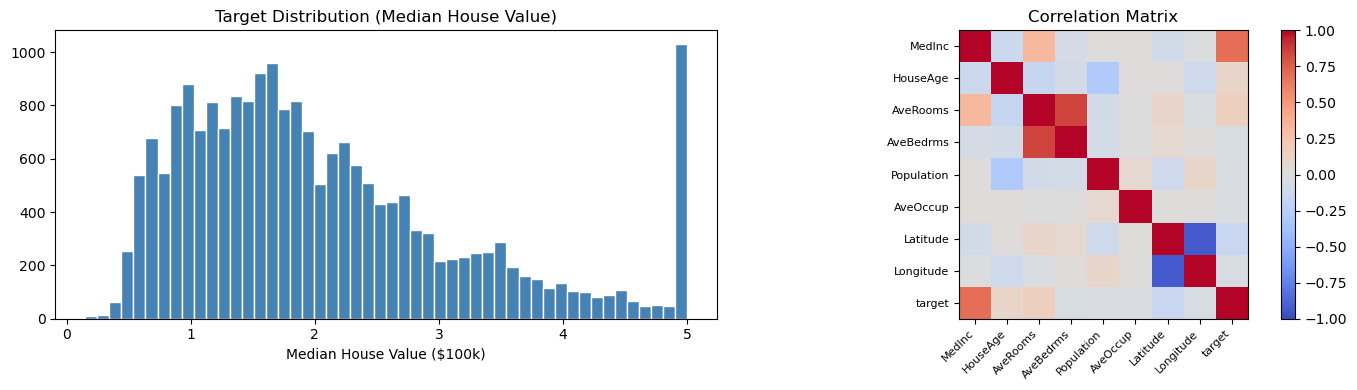

In [3]:
# Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(y, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Target Distribution (Median House Value)')
axes[0].set_xlabel('Median House Value ($100k)')

# Correlation heatmap (simple)
corr = np.corrcoef(np.c_[X, y].T)
im = axes[1].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
labels = list(feature_names) + ['target']
axes[1].set_xticks(range(len(labels)))
axes[1].set_yticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
axes[1].set_yticklabels(labels, fontsize=8)
axes[1].set_title('Correlation Matrix')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train size: {X_train_s.shape}, Test size: {X_test_s.shape}')
print(f'Train feature mean (post-scaling): {X_train_s.mean(axis=0).round(4)}')

Train size: (16512, 8), Test size: (4128, 8)
Train feature mean (post-scaling): [-0. -0.  0. -0. -0. -0.  0. -0.]


## 4. Training
### 4a. Ordinary Least Squares

In [5]:
ols = LinearRegression(method='ols')
ols.fit(X_train_s, y_train)

print('OLS Results:')
print(f'  RMSE : {ols.rmse(X_test_s, y_test):.4f}')
print(f'  R²   : {ols.r2_score(X_test_s, y_test):.4f}')

OLS Results:
  RMSE : 0.7456
  R²   : 0.5758


### 4b. Gradient Descent

Gradient Descent Results:
  RMSE : 0.7457
  R²   : 0.5757


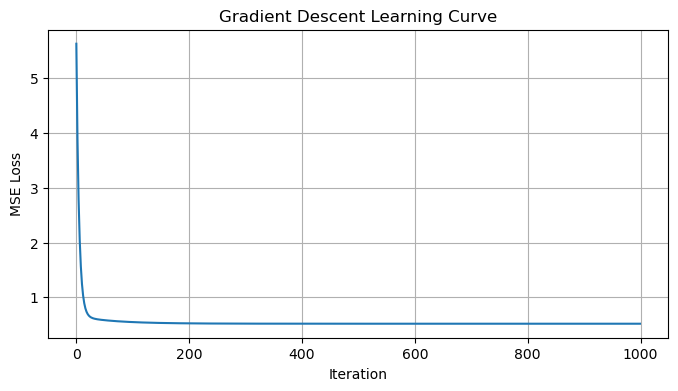

In [6]:
gd = LinearRegression(method='gradient_descent', learning_rate=0.05, n_iterations=1000)
gd.fit(X_train_s, y_train)

print('Gradient Descent Results:')
print(f'  RMSE : {gd.rmse(X_test_s, y_test):.4f}')
print(f'  R²   : {gd.r2_score(X_test_s, y_test):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(gd.loss_history)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent Learning Curve')
plt.grid(True)
plt.show()

## 5. Evaluation & Visualisation

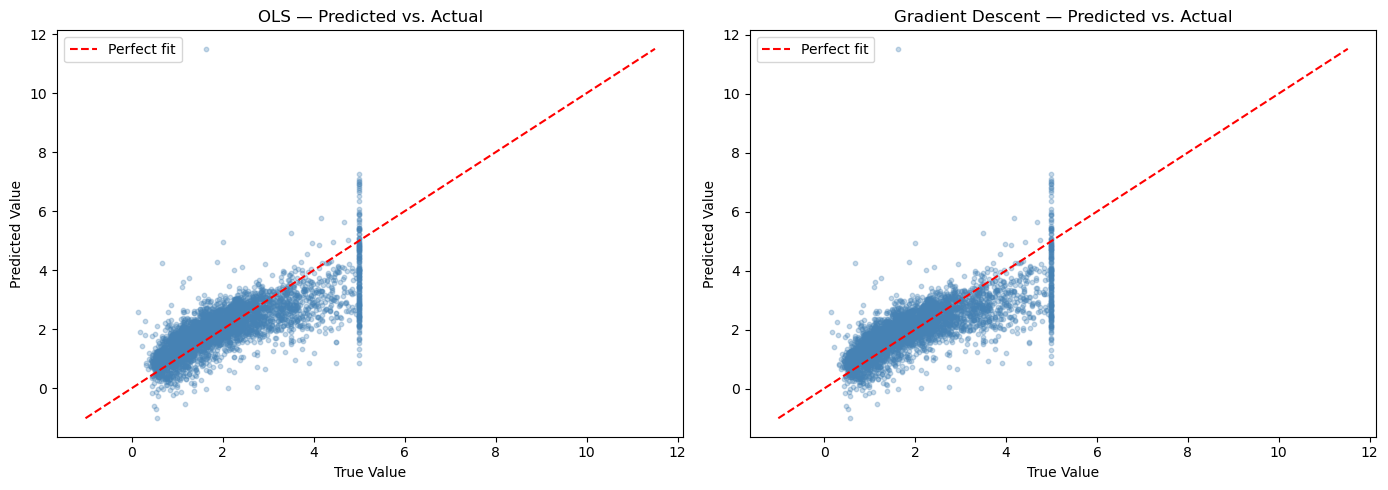

In [7]:
y_pred_ols = ols.predict(X_test_s)
y_pred_gd  = gd.predict(X_test_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in zip(axes, [y_pred_ols, y_pred_gd], ['OLS', 'Gradient Descent']):
    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', label='Perfect fit')
    ax.set_xlabel('True Value')
    ax.set_ylabel('Predicted Value')
    ax.set_title(f'{title} — Predicted vs. Actual')
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Feature Coefficients

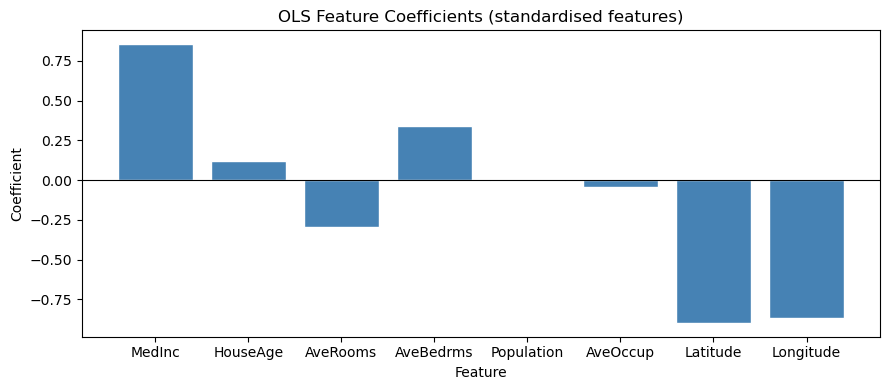

In [8]:
plt.figure(figsize=(9, 4))
plt.bar(feature_names, ols.weights, color='steelblue', edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.title('OLS Feature Coefficients (standardised features)')
plt.tight_layout()
plt.show()

## 7. Comparison with scikit-learn

In [9]:
sk_model = SklearnLR().fit(X_train_s, y_train)
y_pred_sk = sk_model.predict(X_test_s)

results = {
    'rice_ml OLS' : (root_mean_squared_error(y_test, y_pred_ols), r2_score(y_test, y_pred_ols)),
    'rice_ml GD'  : (root_mean_squared_error(y_test, y_pred_gd),  r2_score(y_test, y_pred_gd)),
    'sklearn'     : (root_mean_squared_error(y_test, y_pred_sk),  r2_score(y_test, y_pred_sk)),
}
print(f'{"Model":<15} {"RMSE":>10} {"R²":>10}')
print('-' * 36)
for name, (rmse, r2) in results.items():
    print(f'{name:<15} {rmse:>10.4f} {r2:>10.4f}')

Model                 RMSE         R²
------------------------------------
rice_ml OLS         0.7456     0.5758
rice_ml GD          0.7457     0.5757
sklearn             0.7456     0.5758


## 8. Key Takeaways

- **OLS** provides the globally optimal solution in one step, but requires $O(nd^2 + d^3)$ time for the matrix inversion — impractical for very large $d$.
- **Gradient Descent** scales better and generalises to non-linear models, but requires careful tuning of the learning rate $\eta$.
- The `rice_ml` OLS implementation matches scikit-learn to 4+ decimal places, confirming correctness.
- **MedInc** (median income) is the strongest predictor of house value, as seen in the coefficient plot.